<a href="https://colab.research.google.com/github/vikramvundyala/python_AI-ML/blob/main/C25OverfittingSession2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
X,y = load_iris(return_X_y=True)

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
train_scores = []
test_scores = []
depths = range(1,15)

In [ ]:
for d in depths:
  model = DecisionTreeClassifier(max_depth=d)
  model.fit(X_train,y_train)
  train_scores.append(model.score(X_train,y_train))
  test_scores.append(model.score(X_test,y_test))

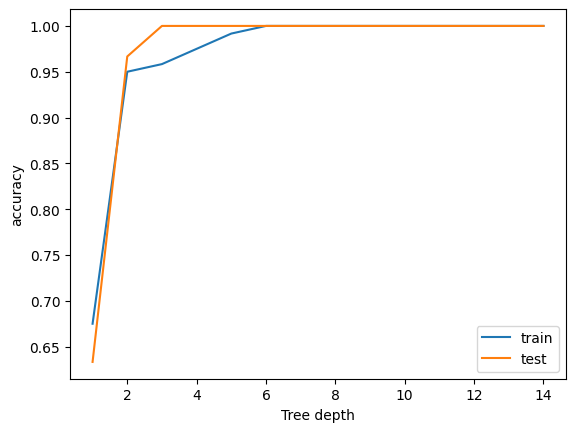

In [ ]:
plt.plot(depths,train_scores,label='train')
plt.plot(depths,test_scores,label='test')
plt.xlabel('Tree depth')
plt.ylabel('accuracy')
plt.legend()
plt.show()

In [ ]:
model.score(X_train,y_train)

1.0

In [ ]:
model.score(X_test,y_test)

1.0

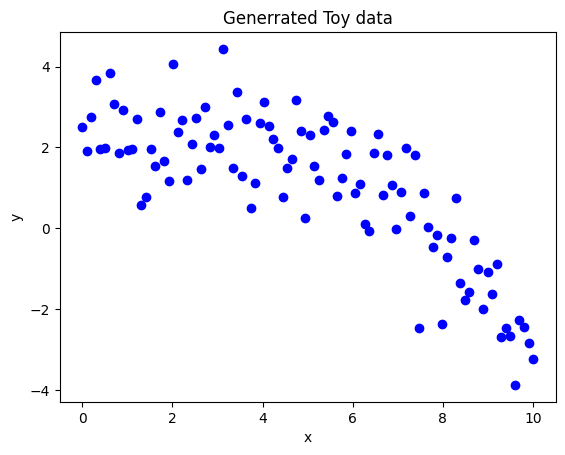

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
X = np.linspace(0,10,100).reshape(-1,1)
y = 2+ 0.5 * X-0.1 * X**2+np.random.normal(scale=1.0,size=X.shape)
plt.scatter(X,y,color='blue',label='True data')
plt.title('Generrated Toy data')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
poly = PolynomialFeatures(degree=15)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
model = LinearRegression()
model.fit(X_train_poly,y_train)

LinearRegression()

In [ ]:
train_preds = model.predict(X_train_poly)
test_preds = model.predict(X_test_poly)

In [ ]:
print('Train MSE',mean_squared_error(y_train,train_preds))
print('Test MSE',mean_squared_error(y_test,test_preds))

Train MSE 0.7930430564004526
Test MSE 0.6778789165055897


In [ ]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
np.random.seed(42)

In [ ]:
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X +np.random.randn(100,1)

In [ ]:
X_extra = np.random.randn(100,5)
X_full = np.hstack((X,X_extra))

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X_full,y,test_size=0.2,random_state=42)

In [ ]:
lr = LinearRegression()
ridge = Ridge(alpha=1)
lasso = Lasso(alpha=0.1)

In [ ]:
lr.fit(X_train,y_train)
ridge.fit(X_train,y_train)
lasso.fit(X_train,y_train)

Lasso(alpha=0.1)

In [ ]:
lr_pred = lr.predict(X_test)
ridge_pred = ridge.predict(X_test)
lasso_pred = lasso.predict(X_test)

In [ ]:
results ={

          "Model":['Linear Regression','Ridge Regression','Lasso Regression'],
          "Train_MSE":[
              mean_squared_error(y_train,lr.predict(X_train)),
              mean_squared_error(y_train,ridge.predict(X_train)),
              mean_squared_error(y_train,lasso.predict(X_train))
          ],
          "Test_MSE":[
              mean_squared_error(y_test,lr_pred),
              mean_squared_error(y_test,ridge_pred),
              mean_squared_error(y_test,lasso_pred)
          ],
          "Coefficiets":
          [
              lr.coef_.flatten(),
              ridge.coef_.flatten(),
              lasso.coef_.flatten()
          ]
}

In [ ]:
import pandas as pd
df_results = pd.DataFrame(results)

In [ ]:
df_results

,Model,Train_MSE,Test_MSE,Coefficiets
0,Linear Regression,0.778419,0.583584,"[2.847447589187203, 0.10584636828805077, 0.046..."
1,Ridge Regression,0.782043,0.587627,"[2.7422148917746183, 0.10710201680014009, 0.03..."
2,Lasso Regression,0.837661,0.660718,"[2.520481007034439, 0.04286376283860026, 0.0, ..."


In [ ]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression()